In [6]:
import pandas as pd

# Load the dataset
df = pd.read_csv('ds_salaries.csv')

df.drop('Unnamed: 0', axis=1, inplace=True)
# Display the first few rows of the dataframe
df.head()

# Display summary statistics and info about the dataset
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary              607 non-null    int64 
 5   salary_currency     607 non-null    object
 6   salary_in_usd       607 non-null    int64 
 7   employee_residence  607 non-null    object
 8   remote_ratio        607 non-null    int64 
 9   company_location    607 non-null    object
 10  company_size        607 non-null    object
dtypes: int64(4), object(7)
memory usage: 52.3+ KB


This dataset provides detailed insights into salary distributions within the data science industry, featuring variables such as work year, experience level, employment type, job title, and employee residence. Notably, it includes the salary both in local currencies and standardized to USD, allowing for a comprehensive analysis across different regions. The data also categorizes companies by size (e.g., small, medium, large), offering a unique perspective on how company size influences salary outcomes. Additional details like remote ratio indicate the extent of remote work, facilitating an understanding of its impact on salary trends. This dataset is instrumental for identifying salary disparities, evaluating employment trends, and informing career decisions in the data science field.

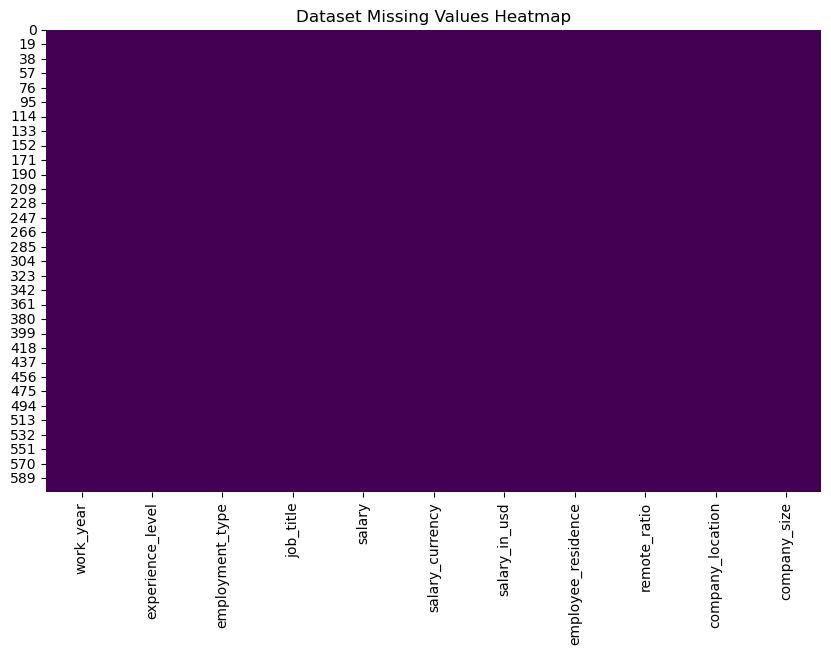

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Dataset Missing Values Heatmap')
plt.show()

All the columns, including work_year, experience_level, employment_type, job_title, salary, salary_currency, salary_in_usd, employee_residence, remote_ratio, company_location, and company_size show no missing values. This suggests that the dataset is complete and robust, providing a solid foundation for any further analysis. Therefore, we just simply move forward with the same dataset.

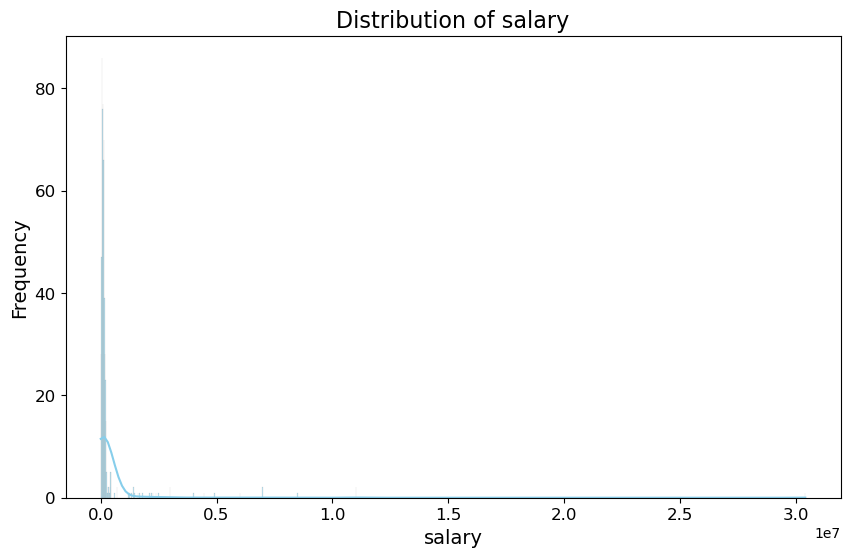

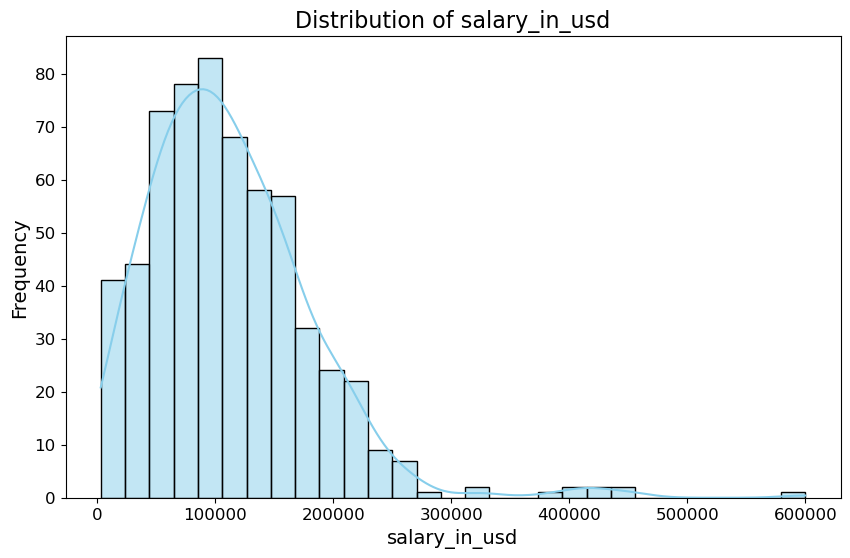

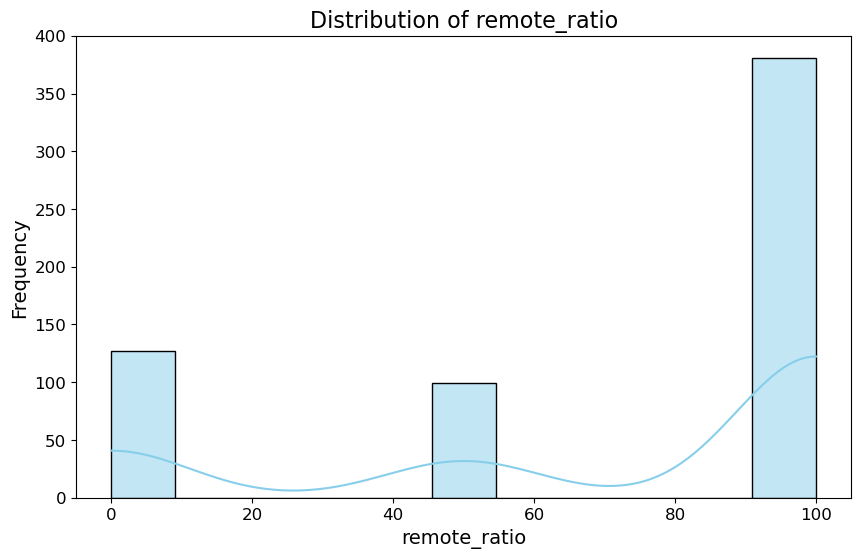

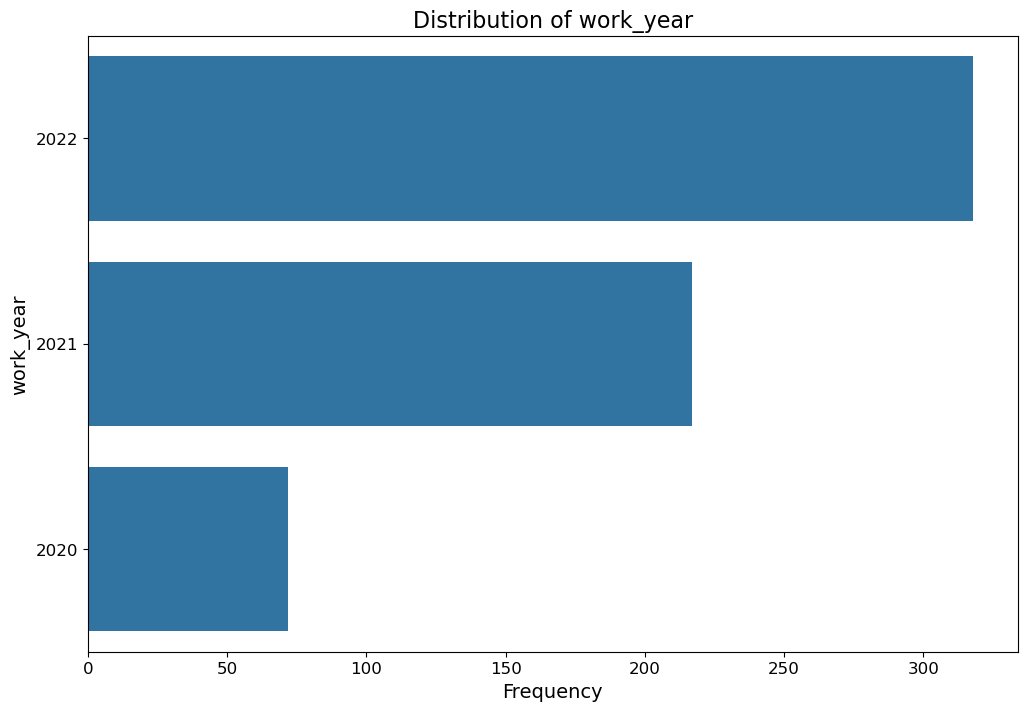

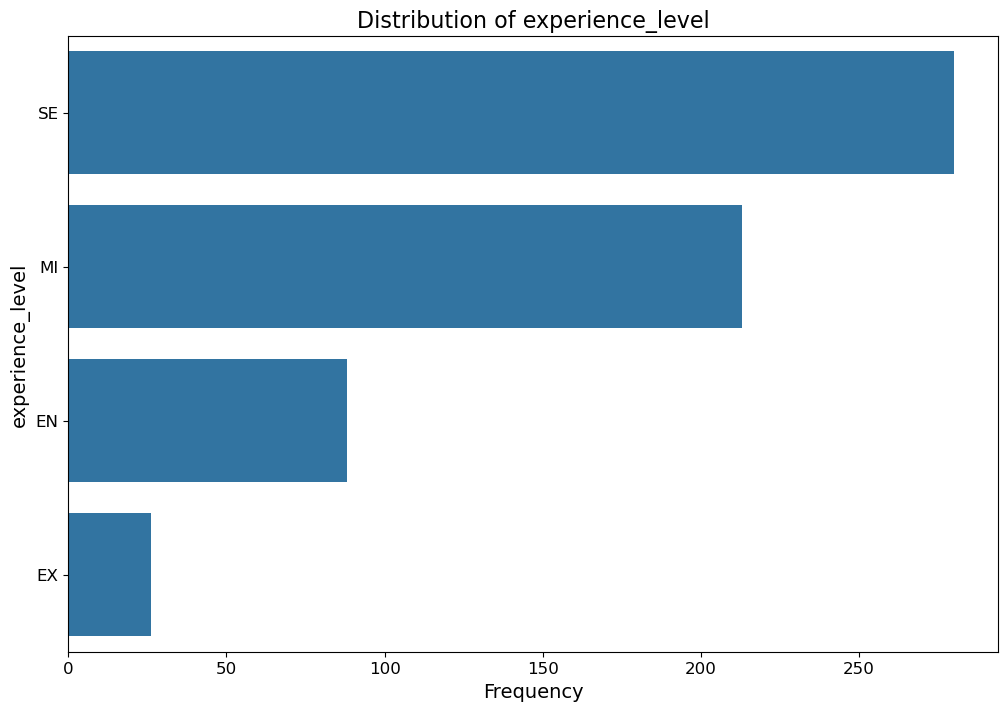

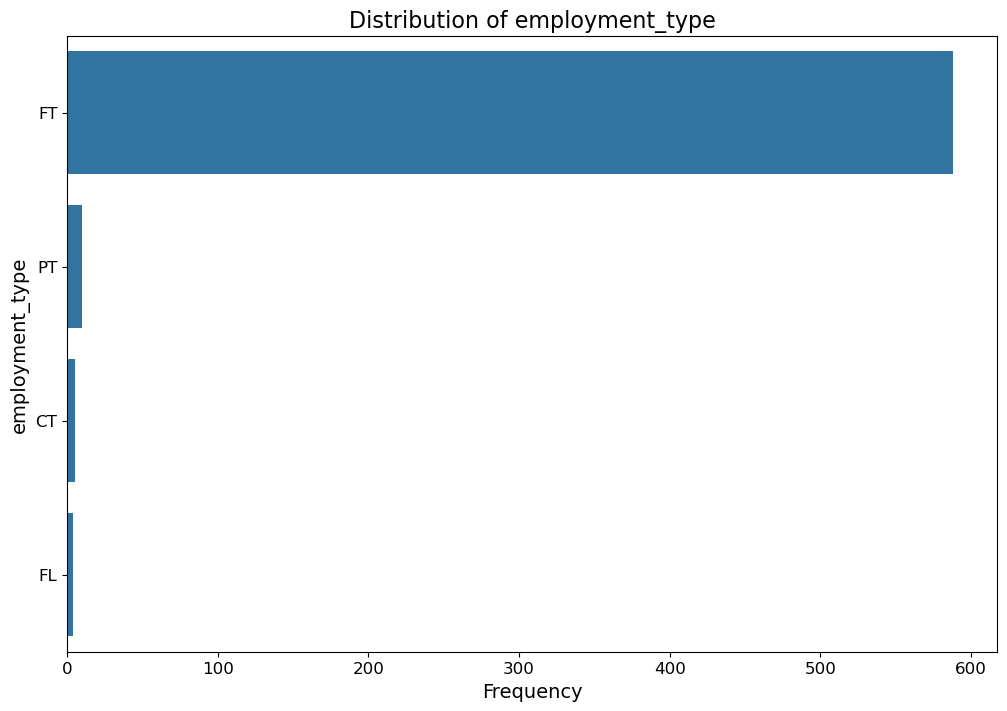

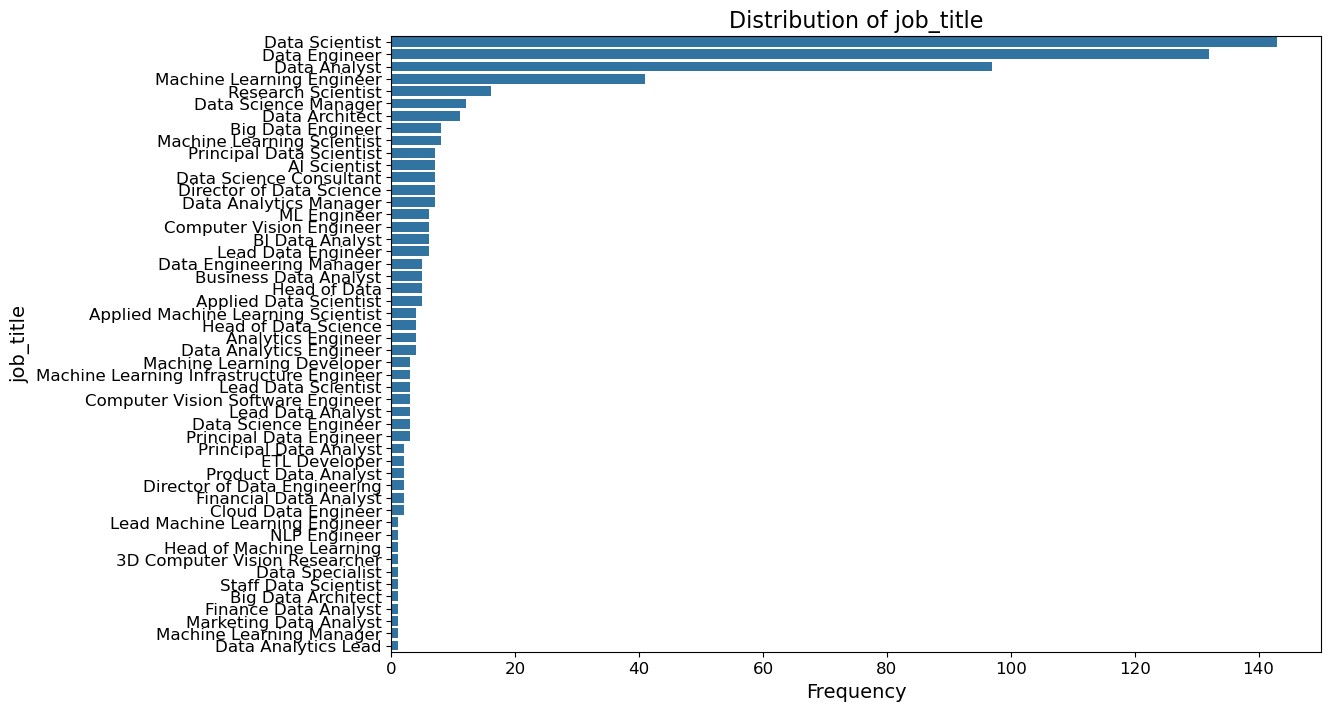

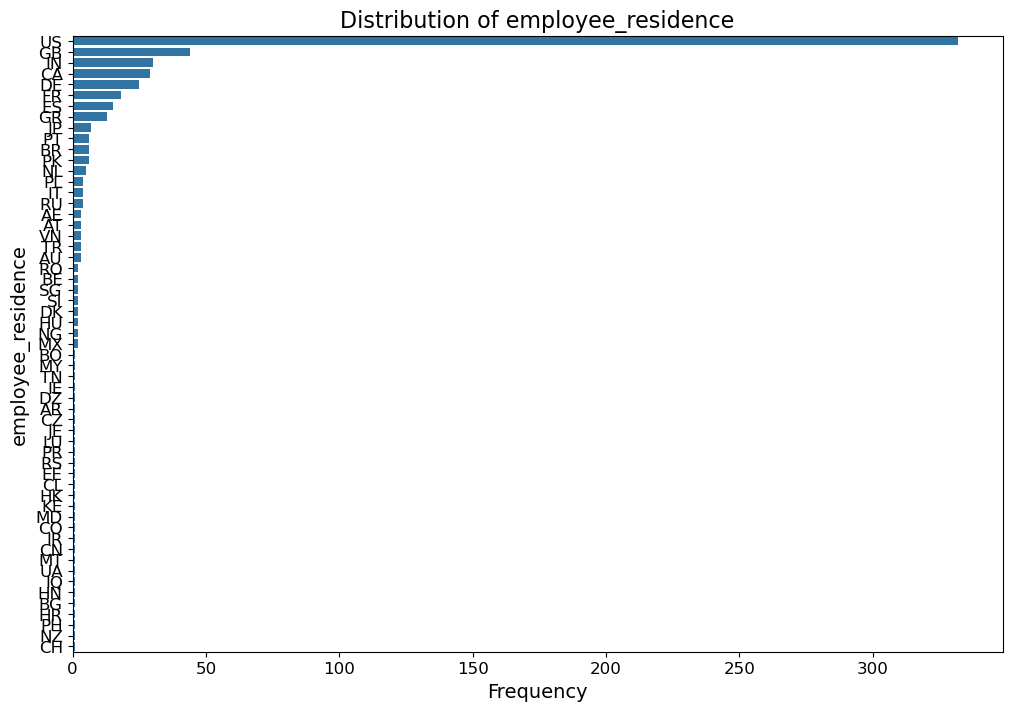

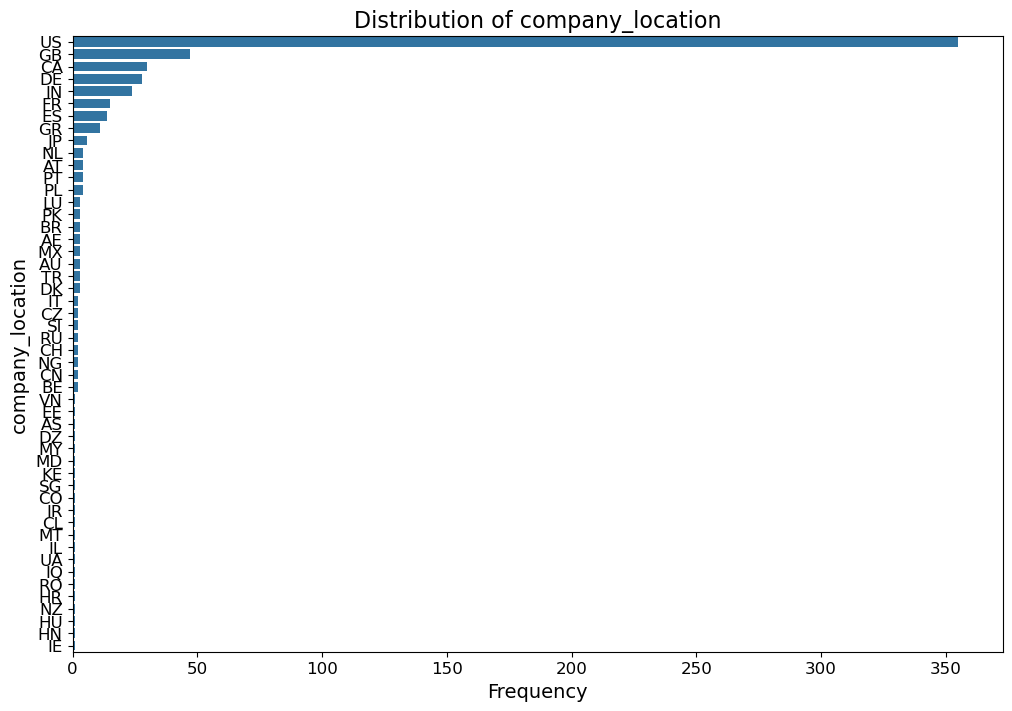

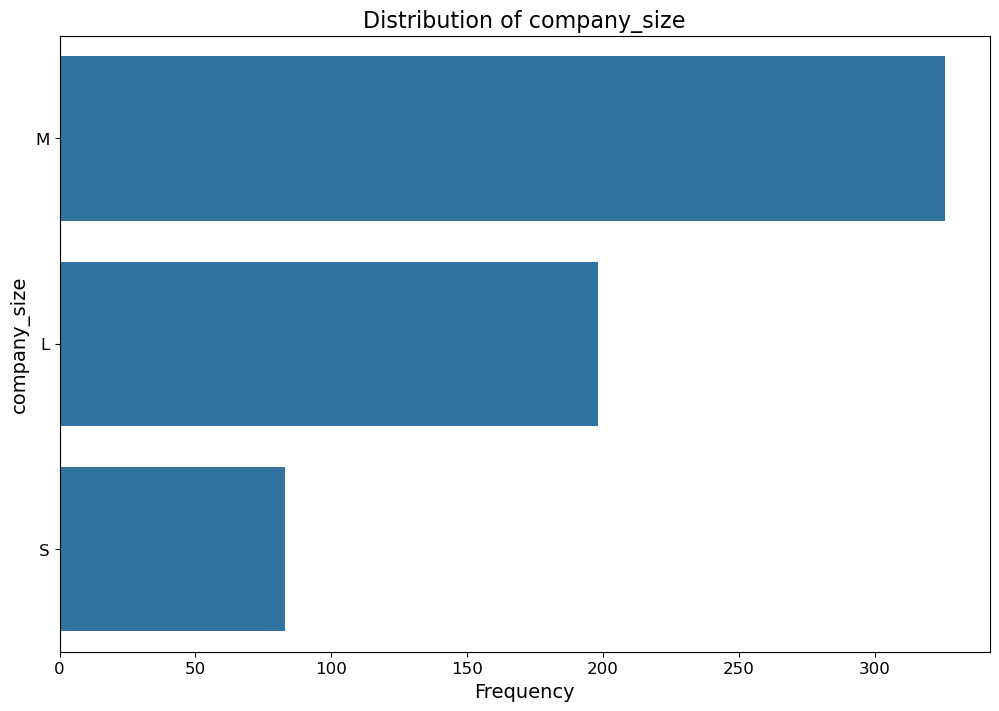

In [10]:
# List of numerical features you want to plot
numerical_features = ['salary', 'salary_in_usd', 'remote_ratio']

# Create histograms for numerical features
for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[feature], kde=True, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {feature}', fontsize=16)
    plt.xlabel(feature, fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()
# List of categorical features you want to plot
categorical_features = ['work_year', 'experience_level', 'employment_type', 'job_title', 'employee_residence', 'company_location', 'company_size']

# Create count plots for categorical features
for feature in categorical_features:
    plt.figure(figsize=(12, 8))
    chart = sns.countplot(y=feature, data=df, order=df[feature].value_counts().index)
    plt.title(f'Distribution of {feature}', fontsize=16)
    plt.xlabel('Frequency', fontsize=14)
    plt.ylabel(feature, fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

/var/folders/vb/xs7b19r91yjfyf7qgryhypp00000gn/T/ipykernel_16662/1830374825.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = df.groupby('work_year').apply(remove_outliers, column='salary_in_usd')


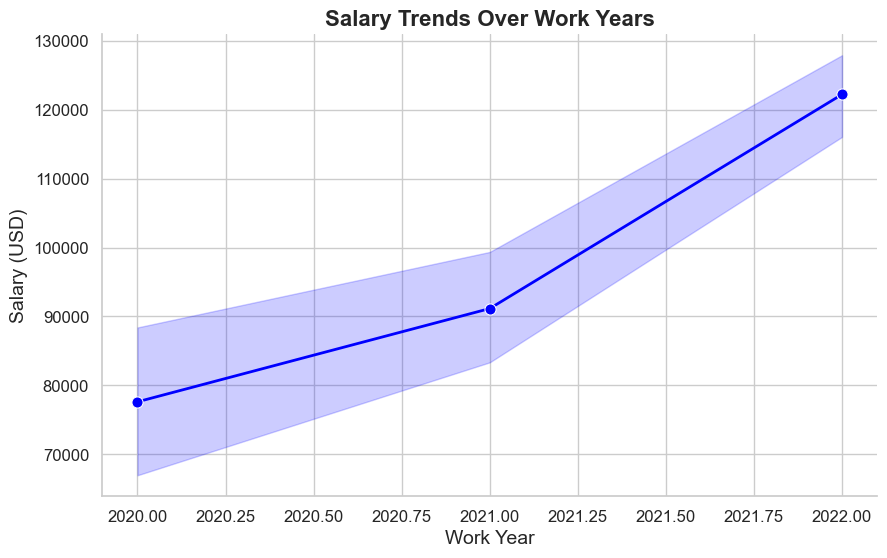

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
filtered_df = df.groupby('work_year').apply(remove_outliers, column='salary_in_usd')
# Set a theme for better aesthetics
sns.set_theme(style="whitegrid")

# Create an improved line plot
plt.figure(figsize=(10, 6))
sns.lineplot(x='work_year', y='salary_in_usd', data=filtered_df, marker='o', color='blue', linewidth=2, markersize=8)

# Add a title and labels with a larger font size
plt.title('Salary Trends Over Work Years', fontsize=16, fontweight='bold')
plt.xlabel('Work Year', fontsize=14)
plt.ylabel('Salary (USD)', fontsize=14)

# Customize the ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Remove the top and right spines for a cleaner look
sns.despine()

# Show the plot
plt.show()

/var/folders/vb/xs7b19r91yjfyf7qgryhypp00000gn/T/ipykernel_16662/1261685814.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = df.groupby('experience_level').apply(remove_outliers, column='salary_in_usd')


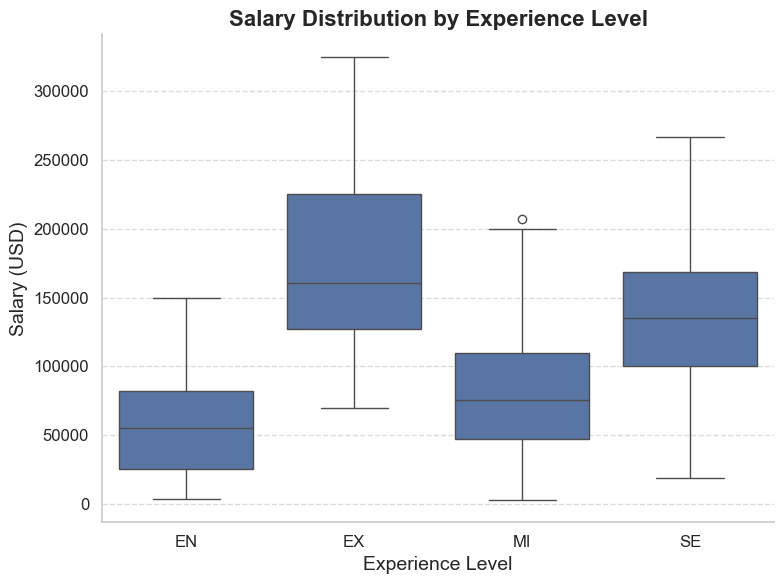

In [28]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
filtered_df = df.groupby('experience_level').apply(remove_outliers, column='salary_in_usd')

    
# Boxplot for Salary by Experience Level
plt.figure(figsize=(8, 6))  # Adjust size for better clarity
sns.boxplot(x='experience_level', y='salary_in_usd', data=filtered_df)

# Add a descriptive title and axis labels
plt.title('Salary Distribution by Experience Level', fontsize=16, fontweight='bold')
plt.xlabel('Experience Level', fontsize=14)
plt.ylabel('Salary (USD)', fontsize=14)

# Customize tick labels
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add grid lines for reference
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Remove spines for a cleaner look
sns.despine()

# Show the plot
plt.tight_layout()
plt.show()

I choose not to use the employment type because it has limited variation and impact on salary compared to other features like job title, experience level, and remote ratio. Most entries in the dataset fall under a dominant category, such as “Full-time,” which reduces the statistical significance of comparisons across employment types. Additionally, employment type may overlap with other features, such as remote work preferences or job titles, making it redundant in the analysis. By excluding employment type, I can focus on more relevant and variable factors that provide deeper insights into salary trends.

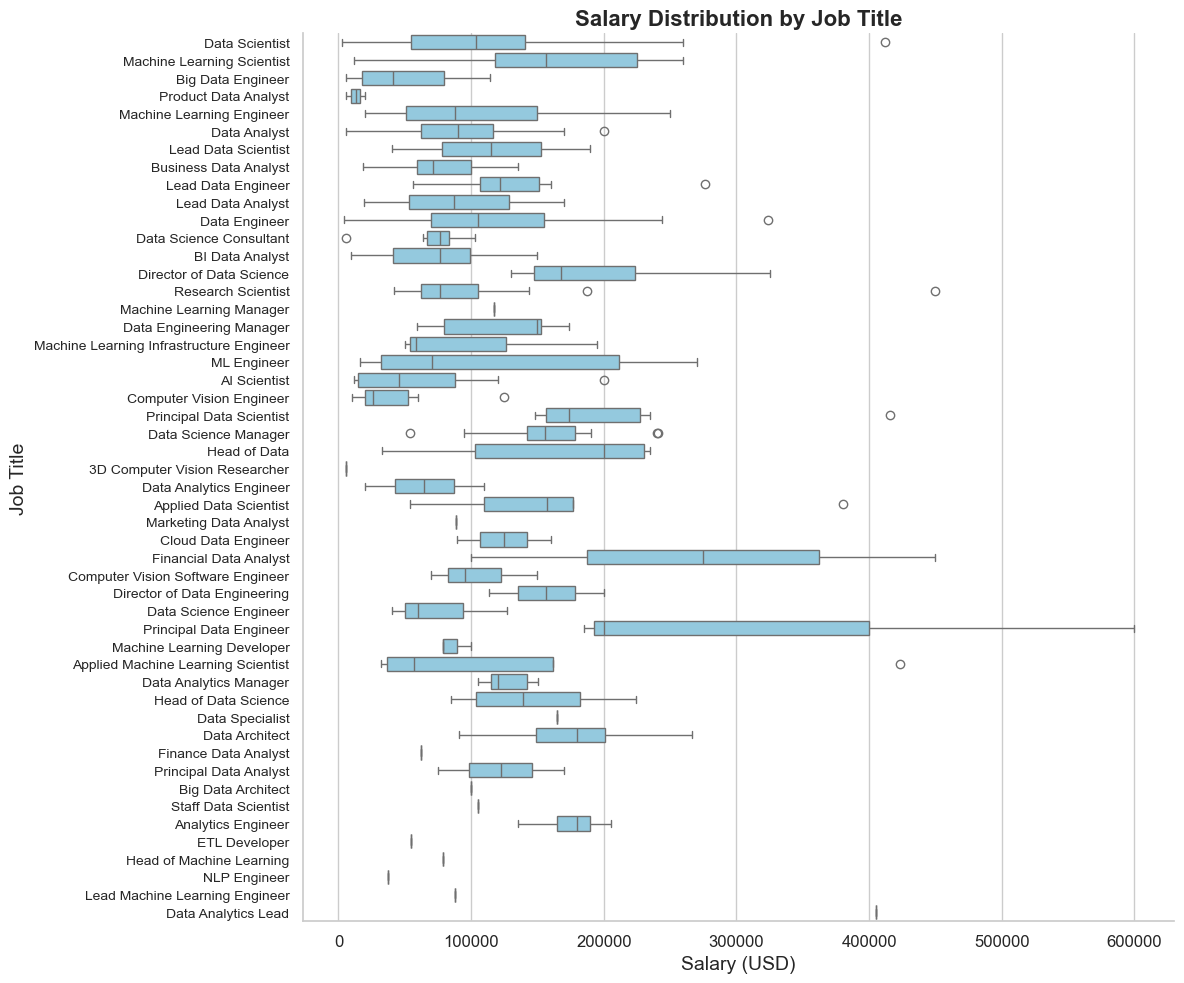

In [81]:
# Improved boxplot for Salary by Job Title with adjusted usage
plt.figure(figsize=(12, 10))  # Increase height for better readability
sns.boxplot(y='job_title', x='salary_in_usd', data=df, color='skyblue')  # Use a single color

# Add a descriptive title and labels with larger font sizes
plt.title('Salary Distribution by Job Title', fontsize=16, fontweight='bold')
plt.xlabel('Salary (USD)', fontsize=14)
plt.ylabel('Job Title', fontsize=14)

# Customize tick labels for readability
plt.xticks(fontsize=12)
plt.yticks(fontsize=10)

# Remove spines for a cleaner look
sns.despine()

# Show the plot
plt.tight_layout()  # Adjust layout to prevent text overlap
plt.show()

Since there are so many job titles and some of them do not have a decent amount of data to identify the relationship with salary, I choose to categorize job titles into broader groups like ‘Data Scientist’, ‘Data Engineer’, ‘Data Analyst’, and ‘Machine Learning Specialist’. 

/var/folders/vb/xs7b19r91yjfyf7qgryhypp00000gn/T/ipykernel_16662/3042250952.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = df.groupby('job_category').apply(remove_outliers, column='salary_in_usd')


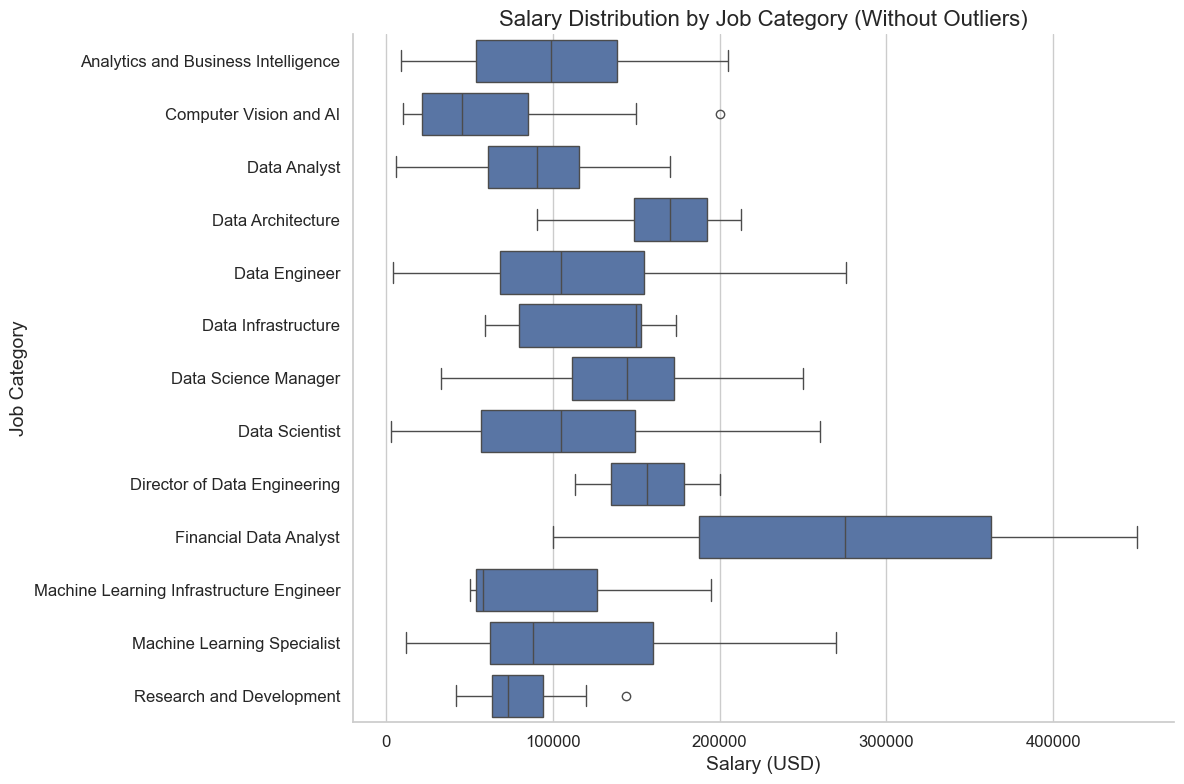

In [30]:
title_mapping = {
    'Data Scientist': [
        'Data Scientist', 'Lead Data Scientist', 'Applied Data Scientist', 'Principal Data Scientist'
    ],
    'Data Engineer': [
        'Data Engineer', 'Lead Data Engineer', 'Big Data Engineer', 'Principal Data Engineer', 'Cloud Data Engineer', 'Big Data Architect'
    ],
    'Machine Learning Specialist': [
        'Machine Learning Specialist', 'Machine Learning Engineer', 'Lead Machine Learning Engineer', 'Head of Machine Learning', 'ML Engineer', 'Machine Learning Developer', 'NLP Engineer', 'Machine Learning Scientist','Machine Learning Manager', 'Head of Machine Learning'
    ],
    'Data Analyst': [
        'Data Analyst', 'Business Data Analyst', 'Principal Data Analyst', 'Product Data Analyst', 'Finance Data Analyst', 'Lead Data Analyst'
    ],
    'Data Science Manager': [
        'Data Science Manager', 'Head of Data Science', 'Director of Data Science', 'Data Science Engineer', 'Data Analytics Manager', 'Data Analytics Lead', 'Machine Learning Manager', 'Head of Data'
    ],
    'Data Infrastructure': [
        'Data Infrastructure Engineer', 'Data Science Infrastructure Engineer', 'Data Engineering Manager'
    ],
    'Research and Development': [
        'Research Scientist', 'Data Science Consultant', '3D Computer Vision Researcher'
    ],
    'Data Architecture': [
        'Data Architect', 'Data Specialist', 'ETL Developer'
    ],
    'Computer Vision and AI': [
        'Computer Vision Engineer', 'Computer Vision Software Engineer', 'AI Scientist', 'Applied Machine Learning Scientist'
    ],
    'Analytics and Business Intelligence': [
        'Data Analytics Engineer', 'BI Data Analyst', 'Analytics Engineer', 'Staff Data Scientist', 'Marketing Data Analyst'
    ]
}

df['job_category'] = df['job_title'].replace({k: v for v, ks in title_mapping.items() for k in ks})
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assume df is your DataFrame and it's already loaded

# Function to remove outliers based on the IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply the function to each job category
# Include the group key by specifying 'group_keys=False' in the groupby function
# Apply the function to each job category, ensuring that the groupby object does not exclude group columns in the apply function
filtered_df = df.groupby('job_category').apply(remove_outliers, column='salary_in_usd')
# Plotting the data without outliers
sns.set(style='whitegrid')
plt.figure(figsize=(12, 8))
sns.boxplot(x='salary_in_usd', y='job_category', data=filtered_df)
plt.title('Salary Distribution by Job Category (Without Outliers)', fontsize=16)
plt.xlabel('Salary (USD)', fontsize=14)
plt.ylabel('Job Category', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

Since salary and currency are used to calculate salary_in_usd, I choose not to include them in the analysis. Including these variables would introduce redundancy, as they are directly related to salary_in_usd and do not provide additional insights beyond what is already captured by the unified salary metric in USD. By focusing solely on salary_in_usd, I ensure a more streamlined and meaningful analysis of salary trends without unnecessary overlap.

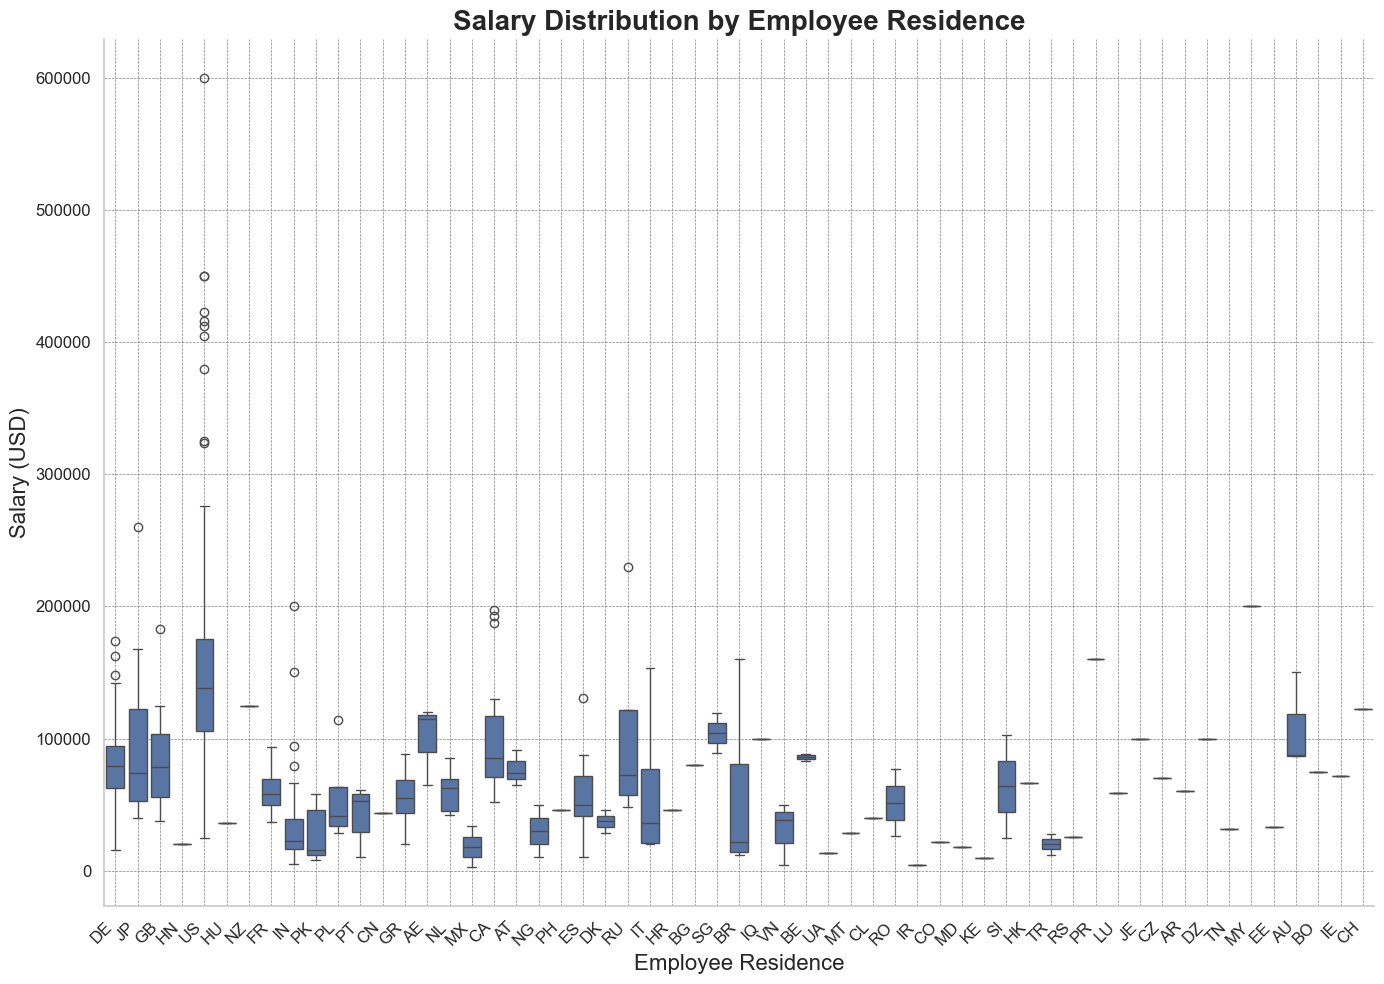

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a larger figure size for better visibility and readability
plt.figure(figsize=(14, 10))

# Create the boxplot with adjusted aesthetics
sns.boxplot(x='employee_residence', y='salary_in_usd', data=df,
            width=0.8)  # Adjust the width of the boxes

# Rotate x-axis labels for better visibility of country names
plt.xticks(rotation=45, fontsize=12, ha='right')  # Adjust rotation and alignment

# Add titles and labels with larger fonts for clarity
plt.title('Salary Distribution by Employee Residence', fontsize=20, fontweight='bold')
plt.xlabel('Employee Residence', fontsize=16)
plt.ylabel('Salary (USD)', fontsize=16)

# Enhance y-axis ticks for better granularity
plt.yticks(fontsize=12)
plt.grid(True, which='major', linestyle='--', linewidth='0.5', color='grey')  # Add grid lines for better analysis

# Improve layout to ensure no label cut-offs
plt.tight_layout()

# Remove the top and right spines for a cleaner look
sns.despine()

# Show the plot
plt.show()

Since there are so many countries, I decided to distinguish them by region, which can include less character.

/var/folders/vb/xs7b19r91yjfyf7qgryhypp00000gn/T/ipykernel_16662/92295795.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = df.groupby('region').apply(remove_outliers, column='salary_in_usd')


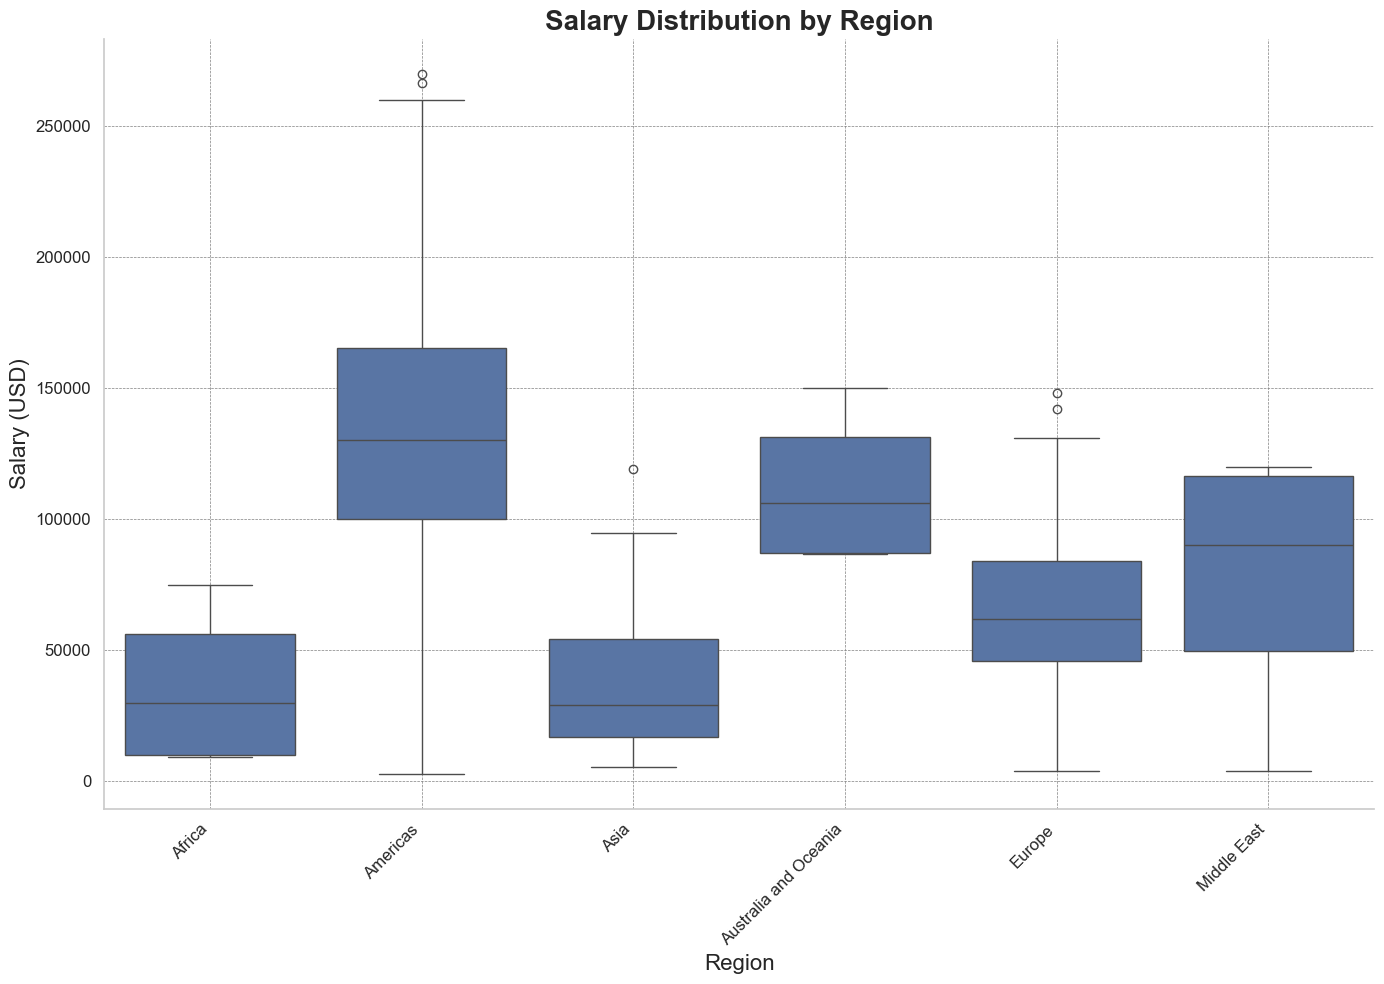

In [34]:
region_mapping = {
    'Americas': [
        'US', 'CA', 'MX',  # North America
        'BR', 'AR', 'CL', 'PE', 'CO', 'VE', 'EC',  # South America
        'HN'  # Central America
    ],
    'Europe': [
        'GB', 'DE', 'FR', 'IT', 'ES', 'NL', 'SE', 'NO', 'PL', 'CH', 'AT', 'BE', 'HU', 'PT', 'GR',
        'DK', 'RU', 'HR', 'BG', 'IQ', 'VN', 'UA', 'MT', 'RO', 'MD', 'SI', 'TR', 'RS', 'PR', 'LU',
        'CZ', 'DZ', 'TN', 'EE', 'LV', 'LT', 'IE','JE'
    ],
    'Asia': [
        'CN', 'JP', 'IN', 'SG', 'HK', 'KR', 'TW', 'TH', 'MY', 'PH','PK'
    ],
    'Australia and Oceania': [
        'AU', 'NZ'
    ],
    'Africa': [
        'ZA', 'NG', 'EG', 'KE', 'GH','BO'
    ],
    'Middle East': [
        'AE', 'SA', 'IL', 'QA', 'OM', 'KW', 'IR'
    ]
}

# Function to apply mapping
def map_residence_to_region(country):
    for region, countries in region_mapping.items():
        if country in countries:
            return region

# Apply the mapping
df['region'] = df['employee_residence'].apply(map_residence_to_region)

def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
filtered_df = df.groupby('region').apply(remove_outliers, column='salary_in_usd')
# Create a boxplot to visualize salary distributions by the mapped region
plt.figure(figsize=(14, 10))
sns.boxplot(x='region', y='salary_in_usd', data=filtered_df, width=0.8)  # Use 'region' instead of 'employee_residence'

# Rotate x-axis labels for better visibility of region names
plt.xticks(rotation=45, fontsize=12, ha='right')  # Adjust rotation and alignment

# Add titles and labels with larger fonts for clarity
plt.title('Salary Distribution by Region', fontsize=20, fontweight='bold')
plt.xlabel('Region', fontsize=16)
plt.ylabel('Salary (USD)', fontsize=16)

# Enhance y-axis ticks for better granularity
plt.yticks(fontsize=12)
plt.grid(True, which='major', linestyle='--', linewidth='0.5', color='grey')  # Add grid lines for better analysis

# Improve layout to ensure no label cut-offs
plt.tight_layout()

# Remove the top and right spines for a cleaner look
sns.despine()

# Show the plot
plt.show()

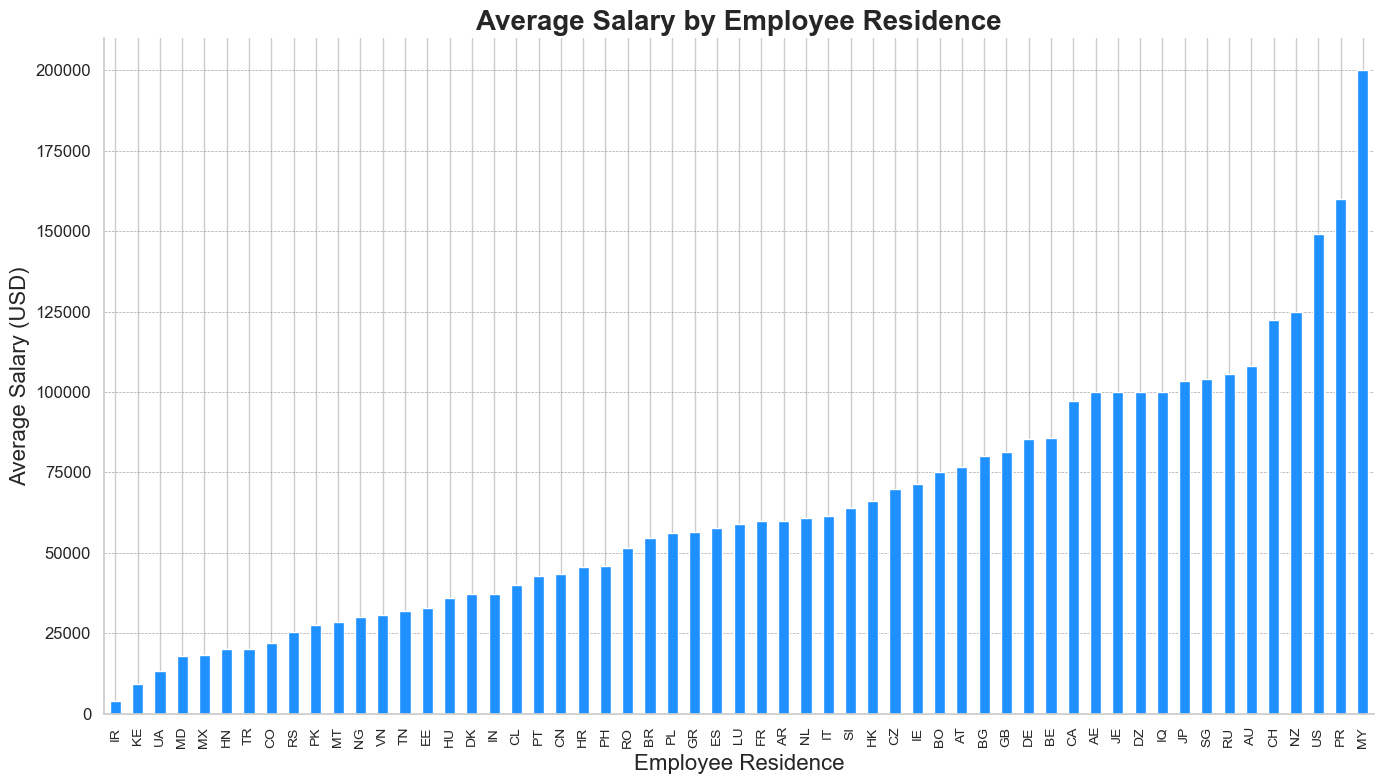

In [92]:
average_salary_by_residence = df.groupby('employee_residence')['salary_in_usd'].mean().sort_values(ascending=False)
plt.figure(figsize=(14, 8))

# Plot the average salary by employee residence using a bar chart
average_salary_by_residence = df.groupby('employee_residence')['salary_in_usd'].mean().sort_values()
average_salary_by_residence.plot(kind='bar', color='dodgerblue')

# Add a descriptive title and axis labels with larger fonts for clarity
plt.title('Average Salary by Employee Residence', fontsize=20, fontweight='bold')
plt.xlabel('Employee Residence', fontsize=16)
plt.ylabel('Average Salary (USD)', fontsize=16)

# Customize tick labels for better readability
plt.xticks(rotation=90, fontsize=10)  # Rotate labels for better readability of country names
plt.yticks(fontsize=12)

# Add grid lines for reference
plt.grid(axis='y', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)

# Improve layout to ensure no label cut-offs
plt.tight_layout()

# Remove the top and right spines for a cleaner look
sns.despine()

# Show the plot
plt.show()

Devide this into regions as well.

/var/folders/vb/xs7b19r91yjfyf7qgryhypp00000gn/T/ipykernel_16662/2102027290.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = df.groupby('region', as_index=False).apply(remove_outliers).reset_index(drop=True)


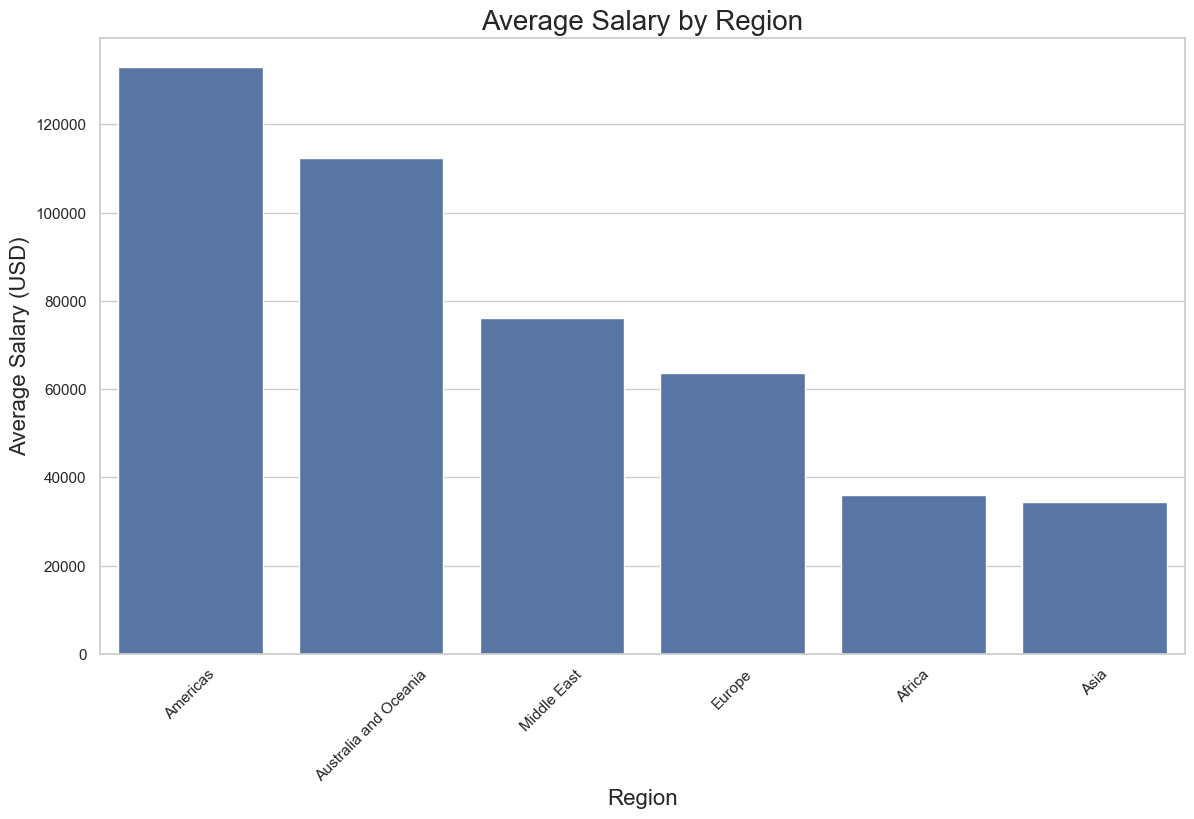

In [51]:
region_mapping = {
    'Americas': [
        'US', 'CA', 'MX',  # North America
        'BR', 'AR', 'CL', 'PE', 'CO', 'VE', 'EC',  # South America
        'HN'  # Central America
    ],
    'Europe': [
        'GB', 'DE', 'FR', 'IT', 'ES', 'NL', 'SE', 'NO', 'PL', 'CH', 'AT', 'BE', 'HU', 'PT', 'GR',
        'DK', 'RU', 'HR', 'BG', 'IQ', 'VN', 'UA', 'MT', 'RO', 'MD', 'SI', 'TR', 'RS', 'PR', 'LU',
        'CZ', 'DZ', 'TN', 'EE', 'LV', 'LT', 'IE','JE'
    ],
    'Asia': [
        'CN', 'JP', 'IN', 'SG', 'HK', 'KR', 'TW', 'TH', 'MY', 'PH','PK'
    ],
    'Australia and Oceania': [
        'AU', 'NZ'
    ],
    'Africa': [
        'ZA', 'NG', 'EG', 'KE', 'GH','BO'
    ],
    'Middle East': [
        'AE', 'SA', 'IL', 'QA', 'OM', 'KW', 'IR'
    ]
}

def map_residence_to_region(country):
    for region, countries in region_mapping.items():
        if country in countries:
            return region
    return 'Other'  # Adding a default category for unmapped or missing country codes

# Apply the mapping
df['region'] = df['employee_residence'].apply(map_residence_to_region)

# Ensure 'region' is not set as an index
df.reset_index(drop=True, inplace=True)

# Function to remove outliers within each region group
def remove_outliers(sub_df):
    Q1 = sub_df['salary_in_usd'].quantile(0.25)
    Q3 = sub_df['salary_in_usd'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return sub_df[(sub_df['salary_in_usd'] >= lower_bound) & (sub_df['salary_in_usd'] <= upper_bound)]

# Apply outlier removal within each region group
filtered_df = df.groupby('region', as_index=False).apply(remove_outliers).reset_index(drop=True)

# Calculate average salary by region
average_salary_by_residence = filtered_df.groupby('region')['salary_in_usd'].mean().sort_values(ascending=False)

# Plotting the results
plt.figure(figsize=(14, 8))
sns.barplot(x=average_salary_by_residence.index, y=average_salary_by_residence.values)
plt.title('Average Salary by Region', fontsize=20)
plt.xlabel('Region', fontsize=16)
plt.ylabel('Average Salary (USD)', fontsize=16)
plt.xticks(rotation=45)
plt.show()

/var/folders/vb/xs7b19r91yjfyf7qgryhypp00000gn/T/ipykernel_16662/1479427009.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = df.groupby('remote_ratio', as_index=False).apply(remove_outliers).reset_index(drop=True)


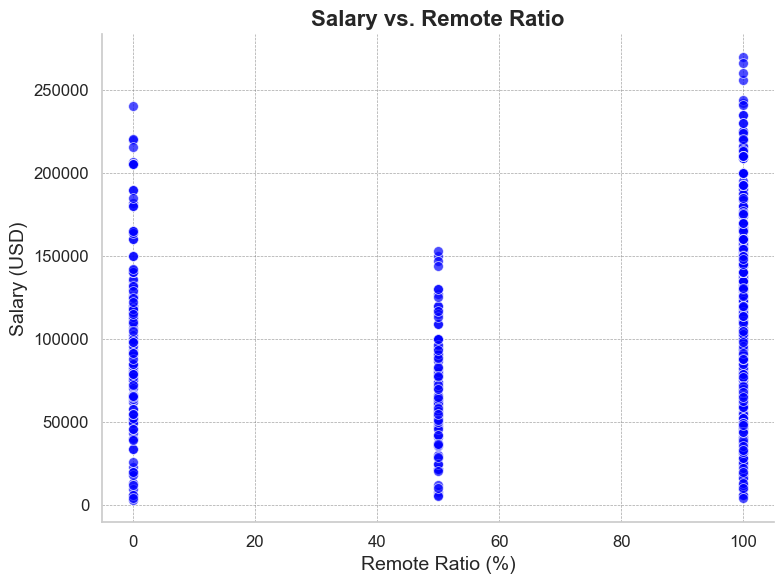

In [55]:
filtered_df = df.groupby('remote_ratio', as_index=False).apply(remove_outliers).reset_index(drop=True)
# Enhanced scatterplot for Salary vs. Remote Ratio
plt.figure(figsize=(8, 6))
sns.scatterplot(x='remote_ratio', y='salary_in_usd', data=filtered_df, alpha=0.7, color='blue', s=50)

# Add a descriptive title and labels with larger font sizes
plt.title('Salary vs. Remote Ratio', fontsize=16, fontweight='bold')
plt.xlabel('Remote Ratio (%)', fontsize=14)
plt.ylabel('Salary (USD)', fontsize=14)

# Customize tick labels for better readability
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add grid lines for reference
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Remove spines for a cleaner look
sns.despine()

# Show the plot
plt.tight_layout()
plt.show()

I will not choose to analyze company_location alongside employee_residence because these variables overlap significantly and could introduce redundancy in the analysis. Both variables essentially represent geographical locations and may reflect similar regional economic conditions, cost of living, and salary scales. Including both could complicate the interpretation of data without adding valuable insights. For instance, a company’s location often corresponds closely with where employees reside, especially in scenarios where remote work is not predominant. This overlap means that examining both separately could lead to misleading conclusions or overstate the importance of location on salary variations. By focusing solely on employee_residence, I can more clearly assess how geographical factors influence salaries without the confounding effects that might arise if company_location were also considered. This approach simplifies the analysis and ensures more straightforward, actionable insights derived from geographical distinctions.

/var/folders/vb/xs7b19r91yjfyf7qgryhypp00000gn/T/ipykernel_16662/3705186458.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = df.groupby('company_size', as_index=False).apply(remove_outliers).reset_index(drop=True)


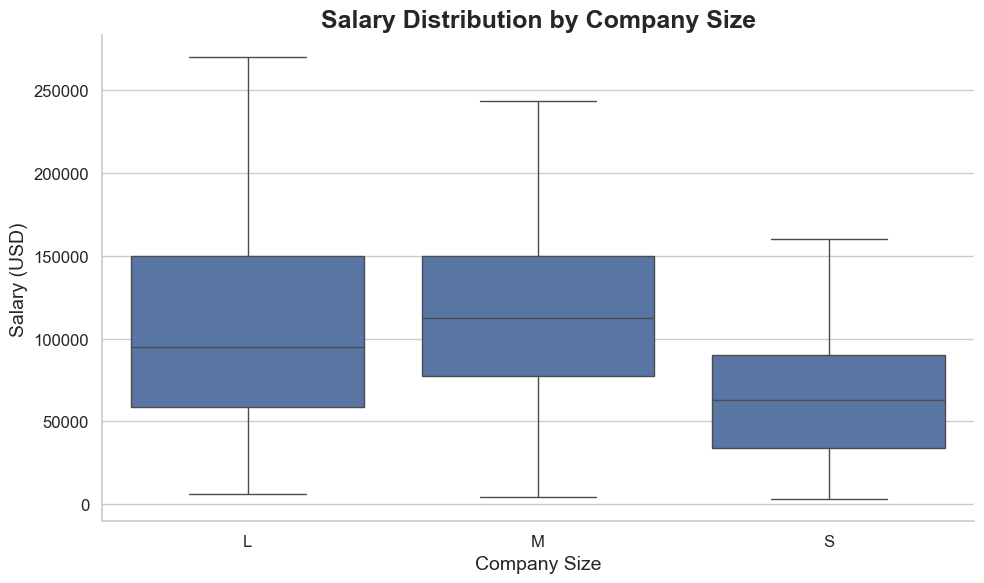

In [57]:
filtered_df = df.groupby('company_size', as_index=False).apply(remove_outliers).reset_index(drop=True)
# Now you can plot using this new 'company_size' column
plt.figure(figsize=(10, 6))
sns.boxplot(x='company_size', y='salary_in_usd', data=filtered_df)
plt.title('Salary Distribution by Company Size', fontsize=18, fontweight='bold')
plt.xlabel('Company Size', fontsize=14)
plt.ylabel('Salary (USD)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

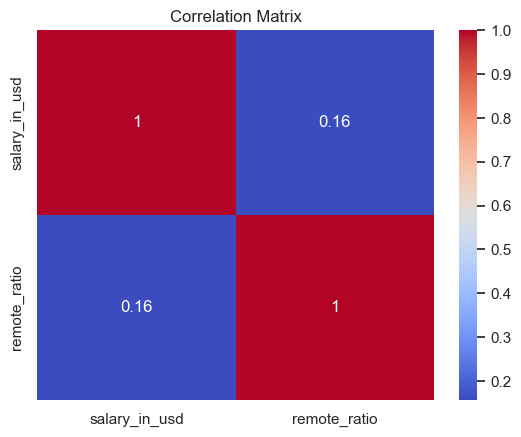

In [59]:
correlation_matrix = df[['salary_in_usd','remote_ratio']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Since there are only two numeric columns, I built a graph to test the correlation. The correlation index is 0.16, which is relatively small. I do not want choose remote as my data therefore.

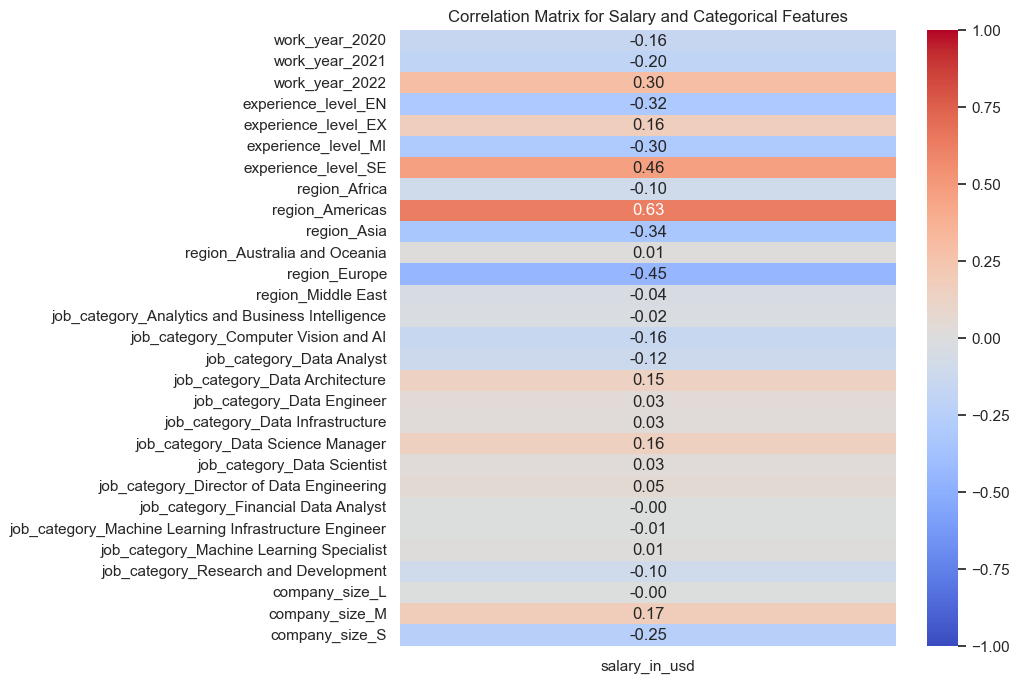

In [61]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Selecting the target and categorical features
target_variable = 'salary_in_usd'
categorical_features = ['work_year', 'experience_level', 'region', 'job_category', 'company_size']

# Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Apply OneHotEncoder to the categorical features
encoded_features = encoder.fit_transform(df[categorical_features])

# Create a DataFrame with the encoded features
encoded_columns = encoder.get_feature_names_out(categorical_features)
encoded_df = pd.DataFrame(encoded_features, columns=encoded_columns)

# Concatenate the target variable back to the encoded dataframe
encoded_df[target_variable] = df[target_variable]

# Calculate the correlation matrix for all encoded features plus the salary
correlation_matrix = encoded_df.corr()

# Filter the matrix to show only correlations with the salary
salary_correlations = correlation_matrix[[target_variable]].drop(target_variable)

# Visualize the correlation matrix
plt.figure(figsize=(8, 8))
sns.heatmap(salary_correlations, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix for Salary and Categorical Features')
plt.show()

From the correlation matrix, we see significant variations in how different regions, experience levels, and job categories correlate with salary. The ‘region_Americas’ notably stands out with a strong positive correlation of 0.63, suggesting higher salaries in this region, making it a crucial factor for further analysis. Additionally, ‘experience_level_SE’ (Senior Level) shows a positive correlation of 0.46 with salary, indicating that higher experience levels generally correspond with higher earnings. These insights are pivotal for understanding the impact of geographical location and experience on salary disparities. Therefore, I choose to advance with ‘region’ and ‘experience_level’ as key features for building the predictive model, as they offer substantial differentiation in salary outcomes and can provide valuable directional insights for strategic compensation planning and talent management.

In [63]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Selecting categorical columns to normalize
categorical_features = ['region', 'experience_level', 'job_category']

# Create the OneHotEncoder object
encoder = OneHotEncoder()  

# Create a column transformer to apply the encoder
column_transformer = ColumnTransformer(
    [("cat", encoder, categorical_features)],
    remainder='passthrough'  # This option allows us to keep the other columns in the DataFrame
)

# Fit and transform the data; it applies OneHotEncoding to the specified categorical features
encoded_data = column_transformer.fit_transform(df)

# Get new column names from the encoder
encoded_columns = column_transformer.named_transformers_['cat'].get_feature_names_out(categorical_features)

# Other columns that were not encoded
remaining_columns = [col for col in df.columns if col not in categorical_features]

# Full list of new column names
new_columns = list(encoded_columns) + remaining_columns

# Construct the new DataFrame
encoded_df = pd.DataFrame(encoded_data, columns=new_columns)

# Display the transformed DataFrame
print(encoded_df.head())
from sklearn.preprocessing import StandardScaler

# Assuming df is your DataFrame and salary_in_usd needs standardization
scaler = StandardScaler()
df['salary_in_usd_scaled'] = scaler.fit_transform(df[['salary_in_usd']])

  region_Africa region_Americas region_Asia region_Australia and Oceania  \
0           1.0             0.0         0.0                          0.0   
1           1.0             0.0         0.0                          0.0   
2           1.0             0.0         0.0                          0.0   
3           1.0             0.0         0.0                          0.0   
4           0.0             1.0         0.0                          0.0   

  region_Europe region_Middle East experience_level_EN experience_level_EX  \
0           0.0                0.0                 1.0                 0.0   
1           0.0                0.0                 0.0                 0.0   
2           0.0                0.0                 1.0                 0.0   
3           0.0                0.0                 0.0                 0.0   
4           0.0                0.0                 0.0                 0.0   

  experience_level_MI experience_level_SE  ... work_year employment_type  

This is the normalized f=key features for further use.